# Quantitative Metrics Evaluation 

Evaluates three models / baselines using the four metrics from the GrooVAE paper:

| Metric | Description |
|--------|-------------|
| **Timing MAE** | Mean absolute error of timing offsets at hit positions (in fractional steps) |
| **Timing MSE** | Mean squared error of timing offsets at hit positions (in fractional steps²) |
| **Velocity KL** | KL(pred ‖ GT) of velocity distributions at hit positions |
| **Timing KL** | KL(pred ‖ GT) of timing-offset distributions at hit positions |

| Row | Description |
|-----|-------------|
| **Baseline** | Fully-quantised input — offset = 0, velocity = GT velocity |
| **Dequant** | Our trained transformer |
| **GrooVAE** | Magenta `groovae_2bar_humanize` (optional — see install note in config cell) |

> **Note on units:** Timing values are in fractional steps, not milliseconds. To convert to ms at 120 BPM / 4 steps per beat: multiply by 125 ms/step.

In [71]:
import io
import sys
import subprocess
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import pretty_midi

# Make the project root importable from within the notebooks/ directory
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.config import CONFIG
from src.data.converters.hov_converter import HOVConverter, HOVConverterConfig
from src.inference.predictor import Predictor, PredictorConfig

MAGENTA_VENV = ROOT / ".venv-magenta"
MAGENTA_PYTHON = MAGENTA_VENV / "bin/python"
MAGENTA_SCRIPT = ROOT / "notebooks/magenta_groovae_infer.py"

# Configuration
CHECKPOINT_PATH = ROOT / ".data/checkpoints/dequant.pt"
CHECKPOINT_PATH_L1 = ROOT / ".data/checkpoints/dequant_l1.pt"
TEST_DATA_DIR = ROOT / ".data/dataset/test"
GROOVAE_CKPT_DIR = ROOT / ".data/groovae_2bar_humanize"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Evaluation window: 32 steps = 2 bars at 4 steps/beat in 4/4 time.
# groovae_2bar_humanize operates on 2-bar (32-step) windows and is specifically
# trained for the humanization task: it preserves the input hit pattern and
# predicts timing offsets + velocities for each hit.
# Using groovae_4bar would be wrong here: that model freely changes hit positions,
# so sampling its output at GT hit positions yields zeros, causing KL to explode.
EVAL_SEQ_LEN = 32
N_SAMPLES = 3655  # number of test sequences (one per track for diversity)
TEMPO_BPM = 120
STEPS_PER_BEAT = CONFIG.model.drums.steps_per_beat  # = 4; used in KL grouping and MAE unit convers

print(f"Device: {DEVICE}")
print(f"Checkpoint: {CHECKPOINT_PATH}")

Device: cuda
Checkpoint: /home/amon/dl4ad/dequant/.data/checkpoints/dequant.pt


In [ ]:
# RUN IN TERMINAL: sudo apt install python3.7 python3.7-venv python3.7-dev libjack-jackd2-dev
# GrooVAE requires its own environment due to magenta/numba incompatibility with Python 3.12.
magenta_venv = str(MAGENTA_VENV)
magenta_python = str(MAGENTA_PYTHON)

!python3.7 -m venv {magenta_venv}
!{magenta_python} -m pip install --upgrade pip setuptools wheel
!{magenta_python} -m pip install numpy==1.21.6 note-seq magenta

# Download GrooVAE model
groovae_ckpt_tar = str(GROOVAE_CKPT_DIR.with_suffix(".tar"))
groovae_ckpt_dir = str(GROOVAE_CKPT_DIR)
groovae_ckpt_dir_parent = str(GROOVAE_CKPT_DIR.parent)

![[ -e {groovae_ckpt_tar} ]] || curl -o {groovae_ckpt_tar} https://storage.googleapis.com/magentadata/models/music_vae/checkpoints/groovae_2bar_humanize.tar
![[ -e {groovae_ckpt_dir} ]] || tar -xf {groovae_ckpt_tar} -C {groovae_ckpt_dir_parent}

## Metric Functions

Implementations follow the definitions in Gillick et al. (2019) §6.2 exactly:

| Metric | Method |
|--------|--------|
| **Timing MAE** | Mean absolute error at GT hit positions, in **milliseconds** |
| **Timing MSE** | Mean squared error at GT hit positions, in **fractions of a 16th note** |
| **Timing KL / Velocity KL** | Analytical **Gaussian KL(pred ‖ GT)**, averaged over 4 beat-subdivision groups |

**KL detail:** notes are split into 4 groups by which 16th-note subdivision they fall on (`step % STEPS_PER_BEAT`: on-beat, e, and, ah). Within each group a Gaussian N(μ, σ) is fit to the predicted values using the *model's own* hit mask, and separately to the GT values using the GT hit mask. The analytical KL formula is applied per group and averaged — matching the paper exactly and avoiding histogram artefacts.

In [57]:
def timing_mae(pred_offsets: np.ndarray, gt_offsets: np.ndarray, hit_mask: np.ndarray) -> float:
    """Mean absolute timing error in milliseconds at GT hit positions (Gillick et al. §6.2)."""
    ms_per_step = 60_000.0 / (TEMPO_BPM * STEPS_PER_BEAT)
    return float(np.abs(pred_offsets[hit_mask] - gt_offsets[hit_mask]).mean() * ms_per_step)


def timing_mse(pred_offsets: np.ndarray, gt_offsets: np.ndarray, hit_mask: np.ndarray) -> float:
    """Mean squared timing error in fractions of a 16th note at GT hit positions."""
    return float(((pred_offsets[hit_mask] - gt_offsets[hit_mask]) ** 2).mean())


def _gaussian_kl(p_vals: np.ndarray, q_vals: np.ndarray) -> float:
    """
    Analytical KL(N(μ_p, σ_p) ‖ N(μ_q, σ_q)).
    Returns nan for degenerate groups (< 2 samples or near-zero variance).
    """
    if len(p_vals) < 2 or len(q_vals) < 2:
        return np.nan
    mu_p, sigma_p = float(np.mean(p_vals)), float(np.std(p_vals))
    mu_q, sigma_q = float(np.mean(q_vals)), float(np.std(q_vals))
    if sigma_p < 1e-8 or sigma_q < 1e-8:
        return np.nan
    return float(np.log(sigma_q / sigma_p) + (sigma_p**2 + (mu_p - mu_q)**2) / (2 * sigma_q**2) - 0.5)


def _kl_by_beat_subdivision(
    pred_vals: np.ndarray,
    gt_vals: np.ndarray,
    pred_hit_mask: np.ndarray,
    gt_hit_mask: np.ndarray,
) -> float:
    """
    Average Gaussian KL(pred ‖ GT) across the 4 beat-subdivision groups
    (step % STEPS_PER_BEAT), as in Gillick et al. (2019) §6.2.

    Each model uses its *own* hit mask so the two distributions are
    independent — not position-matched. This is correct for GrooVAE,
    which may place hits at slightly different positions from GT.
    """
    T = pred_vals.shape[1]
    beat_group = np.arange(T) % STEPS_PER_BEAT  # (T,)

    kl_per_group = []
    for g in range(STEPS_PER_BEAT):
        in_group = beat_group == g                         # (T,)
        p_mask = pred_hit_mask & in_group[None, :, None]
        q_mask = gt_hit_mask   & in_group[None, :, None]
        kl = _gaussian_kl(pred_vals[p_mask], gt_vals[q_mask])
        if not np.isnan(kl):
            kl_per_group.append(kl)

    return float(np.mean(kl_per_group)) if kl_per_group else float("nan")


def velocity_kl(pred_ov: np.ndarray, gt_hov: np.ndarray,
                pred_hit_mask: np.ndarray, gt_hit_mask: np.ndarray) -> float:
    """Gaussian KL(pred_vel ‖ gt_vel) averaged over beat subdivisions."""
    return _kl_by_beat_subdivision(pred_ov[..., 1], gt_hov[..., 2], pred_hit_mask, gt_hit_mask)


def timing_kl(pred_ov: np.ndarray, gt_hov: np.ndarray,
              pred_hit_mask: np.ndarray, gt_hit_mask: np.ndarray) -> float:
    """Gaussian KL(pred_offset ‖ gt_offset) averaged over beat subdivisions."""
    return _kl_by_beat_subdivision(pred_ov[..., 0], gt_hov[..., 1], pred_hit_mask, gt_hit_mask)


def compute_all_metrics(pred_ov: np.ndarray, gt_hov: np.ndarray,
                        pred_hit_mask: np.ndarray | None = None) -> dict:
    """
    Compute all four GrooVAE metrics (Gillick et al. §6.2).

    Args:
        pred_ov:        Predicted (offset, velocity), shape (N, T, I, 2).
        gt_hov:         Ground-truth HOV,             shape (N, T, I, 3).
        pred_hit_mask:  Hit mask for the model,       shape (N, T, I).
                        Defaults to GT hit mask — correct for Baseline and
                        Dequant which always predict at GT hit positions.
                        Pass GrooVAE's own hit mask to compare independent
                        velocity/offset distributions as the paper does.
    """
    gt_hit_mask = gt_hov[..., 0] > 0.5
    if pred_hit_mask is None:
        pred_hit_mask = gt_hit_mask

    return {
        "MAE (ms)":        timing_mae(pred_ov[..., 0], gt_hov[..., 1], gt_hit_mask),
        "MSE (16th note)": timing_mse(pred_ov[..., 0], gt_hov[..., 1], gt_hit_mask),
        "Timing KL":       timing_kl(pred_ov,  gt_hov, pred_hit_mask, gt_hit_mask),
        "Velocity KL":     velocity_kl(pred_ov, gt_hov, pred_hit_mask, gt_hit_mask),
    }

## Load Test Data

In [72]:
def load_test_sequences(data_dir: Path, n_samples: int, seq_len: int = EVAL_SEQ_LEN, seed: int = 42) -> np.ndarray:
    """
    Load one random HOV window per track from test-split npz files, then
    stop once n_samples are collected. Taking one window per track ensures
    diversity across performers rather than sampling many windows from the
    same repetitive recording.

    Returns:
        np.ndarray of shape (n_samples, seq_len, num_instruments, 3).
    """
    rng = np.random.default_rng(seed)
    sequences = []
    npz_files = sorted(data_dir.glob("*.npz"))
    if not npz_files:
        raise FileNotFoundError(f"No .npz files in {data_dir} - run preprocess first.")

    for npz_path in npz_files:
        with np.load(npz_path, allow_pickle=True) as f:
            for track in f["data"]:
                if track is None or len(track) < seq_len:
                    continue
                # One random window per track keeps samples diverse across performers
                max_start = len(track) - seq_len
                start = int(rng.integers(0, max_start + 1))
                sequences.append(track[start : start + seq_len])
                if len(sequences) >= n_samples:
                    break
        if len(sequences) >= n_samples:
            break

    if len(sequences) < n_samples:
        raise ValueError(f"Only {len(sequences)} usable tracks found, need {n_samples}.")

    gt = np.stack(sequences).astype(np.float32)
    print(f"Loaded {len(gt)} test sequences  shape={gt.shape}")
    return gt


gt_hov = load_test_sequences(TEST_DATA_DIR, N_SAMPLES)

Loaded 3655 test sequences  shape=(3655, 32, 9, 3)


## Baseline Inference
*Cache cell - skip re-running if `pred_baseline` already exists.*

The baseline is the fully-quantised input: timing offset = 0 for every hit, velocity copied from ground truth. This represents the input signal before any humanisation model is applied.

In [73]:
def run_baseline(gt_hov: np.ndarray) -> np.ndarray:
    """
    Fully-quantised baseline: offset = 0, velocity = GT velocity.
    Shape: (N, T, instruments, 2).
    """
    pred_ov = np.zeros((*gt_hov.shape[:3], 2), dtype=np.float32)
    pred_ov[..., 1] = np.mean(gt_hov[..., 2], where=(gt_hov[..., 0] > 0.5))   # use average velocity
    return pred_ov


pred_baseline = run_baseline(gt_hov)
print(f"Baseline {pred_baseline.shape}")

Baseline (3655, 32, 9, 2)


## Dequant Model Inference
*Cache cell - skip re-running if `pred_dequant` already exists.*

Feeds the hit-only sequence into `Predictor.process_sequence()` and extracts the predicted (offset, velocity) output.

In [76]:
def run_dequant(gt_hov: np.ndarray, checkpoint_path: Path, device: str) -> np.ndarray:
    """
    Run the Dequant transformer on each test sequence.

    Input:  hit mask from gt_hov[..., 0]   shape (T, instruments).
    Output: predicted (offset, velocity),  shape (N, T, instruments, 2).
    """
    predictor = Predictor(PredictorConfig(checkpoint=checkpoint_path, model=CONFIG.model))
    predictor.model.eval()

    T = gt_hov.shape[1]
    predictions = []

    for i, hov in enumerate(gt_hov):
        print(f"Infering {i + 1}/{len(gt_hov)}")
        hits = torch.from_numpy(hov[..., 0]).float()   # (T, instruments)
        predictor.reset()
        result = predictor.process_sequence(hits)       # (T, instruments, 3)
        ov = result[:, :, 1:3].cpu().numpy()            # (T, instruments, 2)

        # Pad to EVAL_SEQ_LEN if the predictor returned a shorter window
        if len(ov) < T:
            pad = np.zeros((T - len(ov), *ov.shape[1:]), dtype=np.float32)
            ov = np.concatenate([ov, pad], axis=0)
        predictions.append(ov[:T])

    pred_ov = np.stack(predictions).astype(np.float32)
    print(f"Dequant {pred_ov.shape}")
    return pred_ov


CONFIG.model.transformer.n_layers = 1
pred_dequant_l1 = run_dequant(gt_hov, CHECKPOINT_PATH_L1, DEVICE)

CONFIG.model.transformer.n_layers = 5
pred_dequant = run_dequant(gt_hov, CHECKPOINT_PATH, DEVICE)

INFO: checkpoint.py:48: Loading checkpoint from /home/amon/dl4ad/dequant/.data/checkpoints/dequant.pt ...


INFO: predictor.py:143: Predicting 32 steps ...
INFO: predictor.py:143: Predicting 32 steps ...


Infering 1/3655
Infering 2/3655


INFO: predictor.py:143: Predicting 32 steps ...
INFO: predictor.py:143: Predicting 32 steps ...


Infering 3/3655
Infering 4/3655


...

Infering 3650/3655
Infering 3651/3655


INFO: predictor.py:143: Predicting 32 steps ...
INFO: predictor.py:143: Predicting 32 steps ...


Infering 3652/3655
Infering 3653/3655


INFO: predictor.py:143: Predicting 32 steps ...
INFO: predictor.py:143: Predicting 32 steps ...


Infering 3654/3655
Infering 3655/3655
Dequant (3655, 32, 9, 2)


## GrooVAE Inference

In [101]:
import base64

def run_groovae_external(gt_hov):
    _B, T, I, _3 = gt_hov.shape

    converter = HOVConverter(HOVConverterConfig(
        steps_per_beat=CONFIG.model.drums.steps_per_beat,
        categories=CONFIG.model.drums.categories,
        max_seq_len=CONFIG.model.max_seq_len,
    ))

    # Build base64-encoded quantised MIDI inputs:
    # - timing offsets zeroed (on-grid)
    # - GT velocities preserved (matches paper's "quantized drum pattern" input)
    input_midis: list[str] = []
    for hov in gt_hov:
        quantised = hov.copy()
        quantised[..., 1] = 0.0  # no offset
        quantised[..., 2] = quantised[..., 0] * 0.8  # uniform velocity at hit positions

        midi_obj = converter.hov_to_midi(quantised, tempo_bpm=TEMPO_BPM)
        midi_buf = io.BytesIO()
        midi_obj.write(midi_buf)
        input_midis.append(base64.b64encode(midi_buf.getvalue()).decode())

    payload = {
        "input_midis": input_midis,
        "ckpt_dir": str(GROOVAE_CKPT_DIR),
        "eval_seq_len": EVAL_SEQ_LEN,
        "tempo_bpm": TEMPO_BPM,
        "steps_per_beat": STEPS_PER_BEAT,
    }

    process = subprocess.Popen(
        [MAGENTA_PYTHON, MAGENTA_SCRIPT],
        stdin=subprocess.PIPE,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )
    stdout, stderr = process.communicate(json.dumps(payload))

    if process.returncode != 0:
        raise RuntimeError(f"Magenta failed:\n{stderr}")

    output_note_lists = json.loads(stdout)
    category_lookup = converter.config._category_lookup
    predictions = []

    for note_list in output_note_lists:
        hov_out = np.zeros((T, I, 3), dtype=np.float32)
        if note_list is not None:
            for note in note_list:
                step = note["step"]
                if 0 <= step < T:
                    cat = int(category_lookup[note["pitch"]])
                    if 0 <= cat < I:
                        # For duplicate (step, instrument) pairs keep highest velocity
                        if hov_out[step, cat, 0] == 0 or note["velocity"] > hov_out[step, cat, 2]:
                            hov_out[step, cat, 0] = 1.0
                            hov_out[step, cat, 1] = note["offset"]
                            hov_out[step, cat, 2] = note["velocity"]
        predictions.append(hov_out)

    pred_groovae_hov = np.stack(predictions).astype(np.float32)
    print(f"GrooVAE {pred_groovae_hov.shape}")
    return pred_groovae_hov


pred_groovae_hov = run_groovae_external(gt_hov)
print(f"GrooVAE {pred_groovae_hov.shape}")

GrooVAE (3655, 32, 9, 3)
GrooVAE (3655, 32, 9, 3)


## Results

In [103]:
# Baseline and Dequant always predict at GT hit positions -> pred_hit_mask=None.
# GrooVAE may place hits differently -> pass its own hit mask so KL compares
# independent distributions, matching the paper's "aggregate all predicted notes".

model_preds = {
    "Baseline": (pred_baseline, None),
    "Dequant (L5)": (pred_dequant, None),
    "Dequant (L1)": (pred_dequant_l1, None),
    "GrooVAE": (pred_groovae_hov[..., 1:3], pred_groovae_hov[..., 0] > 0.5),
}

metrics = {
    name: compute_all_metrics(pred_ov, gt_hov, pred_hit_mask)
    for name, (pred_ov, pred_hit_mask) in model_preds.items()
}

df = pd.DataFrame(metrics).T
df.index.name = "Model"

df.style \
    .format("{:.4f}") \
    .set_caption(f"GrooVAE Metrics (Gillick et al. 2019) — {N_SAMPLES} test sequences") \
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "1.1em"), ("padding-bottom", "6px")]},
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 12px")]},
    ])


,MAE (ms),MSE (16th note),Timing KL,Velocity KL
Model,,,,
Baseline,18.3185,0.0356,nan,14.8586
Dequant (L5),21.5030,0.0470,0.0899,0.0203
Dequant (L1),18.2287,0.0357,0.8758,0.6193
GrooVAE,18.5084,0.0363,0.4573,0.4455


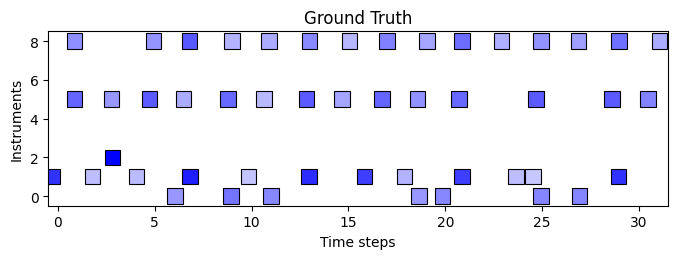

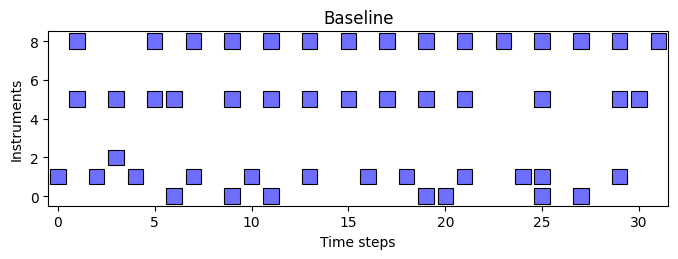

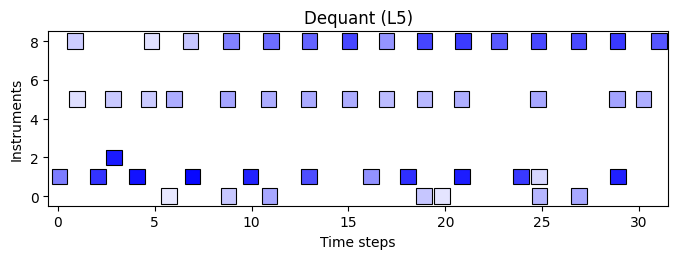

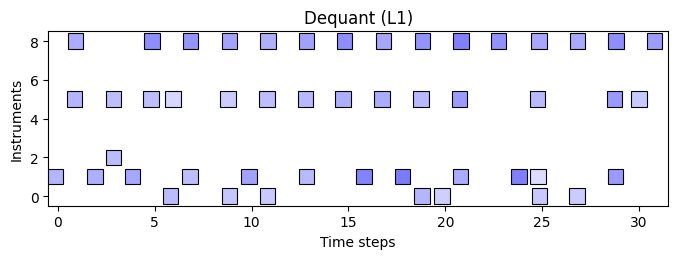

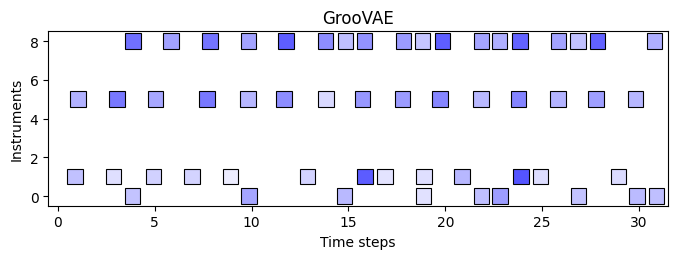

In [106]:
import matplotlib.pyplot as plt

def plot_hov(hov: np.ndarray, title="HOV Tensor"):
    """
    Plot a HOV tensor of shape (T, I, 3)
    hov[..., 0] -> hit (0/1)
    hov[..., 1] -> x-offset (-0.5..0.5)
    hov[..., 2] -> velocity (0..1)
    """
    T, I, _ = hov.shape
    fig, ax = plt.subplots(figsize=(T/4, I/2))

    rect_width = 0.8
    rect_height = 0.8

    for t in range(T):
        for i in range(I):
            hit, offset, velocity = hov[t, i]
            if hit > 0:
                x = t + offset - rect_width/2
                y = i - rect_height/2

                # fill
                rect = plt.Rectangle(
                    (x, y),
                    rect_width,
                    rect_height,
                    facecolor='blue',
                    alpha=float(np.clip(velocity, 0.0, 1.0)),
                    edgecolor=None
                )
                ax.add_patch(rect)

                # outline
                rect_outline = plt.Rectangle(
                    (x, y),
                    rect_width,
                    rect_height,
                    facecolor='none',
                    edgecolor='black',
                    linewidth=0.8
                )
                ax.add_patch(rect_outline)
    
    ax.set_xlim(-0.5, T-0.5)
    ax.set_ylim(-0.5, I-0.5)
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Instruments")
    ax.yaxis.set_inverted(True)
    ax.set_title(title)
    ax.set_aspect('equal')
    plt.gca().invert_yaxis()  # optional: top instrument at top
    plt.show()

index = 13
plot_hov(gt_hov[index], "Ground Truth")
plot_hov(np.concatenate([gt_hov[index, ..., :1], pred_baseline[index]], axis=-1), "Baseline")
plot_hov(np.concatenate([gt_hov[index, ..., :1], pred_dequant[index]],  axis=-1), "Dequant (L5)")
if pred_dequant_l1 is not None:
    plot_hov(np.concatenate([gt_hov[index, ..., :1], pred_dequant_l1[index]], axis=-1), "Dequant (L1)")
# GrooVAE: use its own full HOV so hits appear at GrooVAE's actual positions
plot_hov(pred_groovae_hov[index], "GrooVAE")

## Cache

In [104]:
# ======== STORE MATRICES ========

CACHE_PATH = ROOT / ".data/test_predictions.npz"

save_dict = {
    "gt_hov": gt_hov,
    "pred_baseline": pred_baseline,
    "pred_dequant": pred_dequant,
    "pred_dequant_l1": pred_dequant_l1,
    "pred_groovae_hov": pred_groovae_hov,
}

np.savez_compressed(CACHE_PATH, **save_dict)
print(f"Saved to {CACHE_PATH}")

Saved to /home/amon/dl4ad/dequant/.data/test_predictions.npz


In [105]:
# ======== LOAD MATRICES ========

CACHE_PATH = ROOT / ".data/test_predictions.npz"

# Don't overwrite existing prediction values in the current session
if set(["pred_dequant", "pred_dequant_l1", "pred_groovae_hov"]) & set(globals().keys()):
    raise ValueError("Some prediction cells have already been run and their results would be overwritten. Please clear all variables/restart the kernel before loading from cache.")

data = np.load(CACHE_PATH, allow_pickle=False)
gt_hov = data["gt_hov"]
pred_baseline = data["pred_baseline"]
pred_dequant = data["pred_dequant"]
pred_dequant_l1 = data["pred_dequant_l1"]
pred_groovae_hov = data["pred_groovae_hov"]

print(f"Restored from {CACHE_PATH}")

ValueError: Some prediction cells have already been run and their results would be overwritten. Please clear all variables/restart the kernel before loading from cache.